In [1]:
import numpy as np
import matplotlib.pyplot as plt
import io
import matplotlib.colors as mcolors
import requests
import xarray as xr

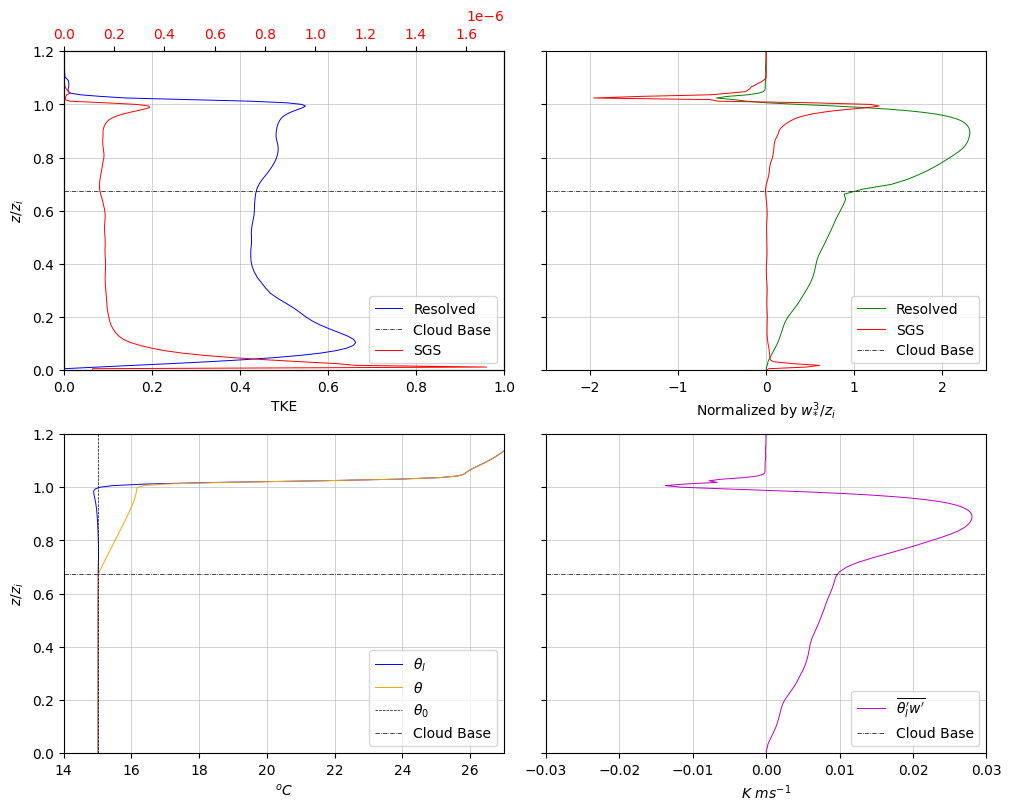

In [11]:
#---Cloud base (last time steo)---
zi=830
c_base=560/zi

#---Normalization (last time step)---
w_star=0.71
norm=w_star**3/zi

#---Buoyancy data---
url4="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/Buoyancy_TKE_FLUX_data.nc"
response=requests.get(url4)
data=response.content
bf=xr.open_dataset(io.BytesIO(data),engine="h5netcdf")
theta0=bf.PTL.values[0]-273.15 # Surface liquid potential temperature

fig,ax=plt.subplots(2,2,figsize=(10,8),constrained_layout=True)
ax[1,0].plot(bf.PTL.values-273.15,bf.z.values,linewidth=0.7,color="b",label=r"$\theta_l$")
ax[1,0].plot(bf.PT.values-273.15,bf.z.values,color="orange",linewidth=0.7,label=r"$\theta$")
ax[1,1].plot(bf.PTLW.values,bf.z.values,color="m",linewidth=0.7,label=r"$\overline{\theta_l^\prime w^\prime}$ ")
ax[0,1].set_yticklabels([])
ax[0,1].plot(bf.BFRES.values/norm,bf.z.values,linewidth=0.7,color="g",label="Resolved")
ax[0,1].plot(bf.BFSGS.values/norm,bf.z.values,linewidth=0.7,color="r",label="SGS")
ax[0,0].plot(bf.TKERES.values, bf.z.values, linewidth=0.7, color="b", label="Resolved")
ax[1,1].set_yticklabels([])
ax[1,0].axvline(x=theta0,linewidth=0.5,color="k",label="$\\theta_0$",linestyle="--")
xlabels=["TKE","Normalized by $w_{*}^{3}/z_{i}$","${}^oC$","$K$ $ms^{-1}$"]

# Create secondary x-axis for ax[1,1] (SGS TKE)
ax_twin = ax[0,0].twiny()
ax_twin.plot(bf.TKESGS.values, bf.z.values, linewidth=0.7, color="r", label="SGS")
ax_twin.tick_params(axis='x', labelcolor='r')
ax_twin.xaxis.set_ticks_position('top')
ax_twin.xaxis.set_label_position('top')
i=0
for a_single_ax in ax.flat:
  a_single_ax.set_ylim([0,1.2])
  a_single_ax.set_xlabel(xlabels[i])
  a_single_ax.grid(True,linewidth=0.5,alpha=0.8)
  a_single_ax.axhline(y=c_base,linewidth=0.5,color="k",label="Cloud Base",linestyle="-.")
  if a_single_ax != ax[0,0]:
      a_single_ax.legend(loc="lower right")
  i+=1
handles1, labels1 = ax[0,0].get_legend_handles_labels()
handles2, labels2 = ax_twin.get_legend_handles_labels()
ax_twin.set_xlim([0,1.75e-6])
ax[0,0].legend(handles1 + handles2, labels1 + labels2, loc='lower right')
ax[0,0].set_xlim([0,1])
ax[1,0].set_xlim([14,27])
ax[1,1].set_xlim([-0.03,0.03])
ax[0,1].set_xlim([-2.5,2.5])
ax[0,0].set_ylabel("$z/z_i$")
ax[1,0].set_ylabel("$z/z_i$")
plt.show()